In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import pyodbc
import numpy as np
import pickle

### Functions

In [2]:
def read_sql_script(str_local_path):
    str_query = open(str_local_path, 'r').read()
    return str_query

In [3]:
def pull_data_from_sql(str_query, conn, bool_close_conn=True):
    df = pd.read_sql_query(
        sql=str_query,
        con=conn,
    )
    if bool_close_conn:
        conn.close()
    else:
        pass
    return df

In [13]:
class GetData:
    def __init__(self):
        pass
    def read_sql_script(self, str_local_path):
        str_query = open(str_local_path, 'r').read()
        # save to object
        self.str_query = str_query
        # return object
        return self
    def pull_data_from_sql(self, conn, bool_close_conn=True):
        df = pd.read_sql_query(
            sql=self.str_query,
            con=conn,
        )
        if bool_close_conn:
            conn.close()
        else:
            pass
        return df

In [33]:
def categorize_fltgrossmonthly(fltGrossMonthly):
    if fltGrossMonthly < 2000:
        return 'Low'
    else:
        return 'Not Low'

### Constants

In [27]:
str_project = os.getcwd().split('\\')[3]
print(f'Project: {str_project}')

str_task = os.getcwd().split('\\')[4]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('\\')[5]
print(f'Subtask: {str_subtask}')

str_dirname_output = './output'

Project: 20240521_bridger_internship
Task: 03_python
Subtask: 01_jupyter_practice


### Make output directory

In [6]:
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    pass

### Read SQL

In [14]:
str_filename = 'Tblincome.sql'
str_local_path = f'./sql/{str_filename}'
str_query = read_sql_script(
    str_local_path=str_local_path,
)
str_query

"SELECT TOP 10000 bigIncomeId, dtmStampCreation, fltGrossMonthly, strEmployerName, intMonths, intYears\nFROM electra.pfsdb.dbo.tblincome\nWHERE dtmStampCreation >= '2020'\nORDER BY dtmStampCreation DESC;\n"

### Pull data into data frame

In [15]:
conn = pyodbc.connect(
    'Driver={SQL Server};'
    'Server=electra;'
    'Database=pfsdb;'
    'Trusted_connection=yes;'
)
df = pull_data_from_sql(
    str_query=str_query, 
    conn=conn, 
    bool_close_conn=True,
)
df

C:\Users\bhyde\AppData\Local\Temp\ipykernel_8524\4148004108.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(


,bigIncomeId,dtmStampCreation,fltGrossMonthly,strEmployerName,intMonths,intYears
0,13785730,2024-05-28 14:13:25.847,4000.00,NAIL SALON CLIENT SERVICES,4.0,0.0
1,13785729,2024-05-28 14:12:33.707,3000.00,community spirts,6.0,1.0
2,13785728,2024-05-28 14:12:26.120,7300.00,TEAMSTERS UNION,0.0,25.0
3,13785727,2024-05-28 14:12:18.000,3852.00,SUDDATH,1.0,0.0
4,13785726,2024-05-28 14:11:59.993,12617.77,Weyerhaeuser Company,5.0,3.0
...,...,...,...,...,...,...
9995,13775736,2024-05-24 14:43:36.837,2136.00,None,NaN,NaN
9996,13775734,2024-05-24 14:43:35.013,5867.00,Parkhurst Dining,0.0,1.0
9997,13775733,2024-05-24 14:43:03.023,3500.00,OAK STREET HEALTH,4.0,0.0
9998,13775732,2024-05-24 14:43:02.303,0.00,"Big Lots, Inc.",NaN,NaN


### Do the same thing but use a class

#### Initialize class

In [16]:
cls_get_data = GetData()
# call method off of class
str_filename = 'Tblincome.sql'
str_local_path = f'./sql/{str_filename}'
cls_get_data.read_sql_script(
    str_local_path=str_local_path,
)
# show the attribute
#cls_get_data.str_query

#### Pickle the class with the attributes in the object

In [17]:
# pickle class and show that the attribute still exists
str_filename = 'cls_get_data.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
# save
pickle.dump(cls_get_data, open(str_local_path, 'wb'))

#### Read the pickled class

In [18]:
# read file
str_filename = 'cls_get_data.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
cls_get_data = pickle.load(open(str_local_path, 'rb'))

#### Pull data

In [19]:
# pull the data using a method
conn = pyodbc.connect(
    'Driver={SQL Server};'
    'Server=electra;'
    'Database=pfsdb;'
    'Trusted_connection=yes;'
)
df = cls_get_data.pull_data_from_sql(
    conn=conn,
    bool_close_conn=True,
)
df

C:\Users\bhyde\AppData\Local\Temp\ipykernel_8524\3525508220.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(


,bigIncomeId,dtmStampCreation,fltGrossMonthly,strEmployerName,intMonths,intYears
0,13785731,2024-05-28 14:13:32.963,6830.0,walmart super center,4.0,10.0
1,13785732,2024-05-28 14:13:32.963,3000.0,Hollywood Feed,3.0,0.0
2,13785730,2024-05-28 14:13:25.847,4000.0,NAIL SALON CLIENT SERVICES,4.0,0.0
3,13785729,2024-05-28 14:12:33.707,3000.0,community spirts,6.0,1.0
4,13785728,2024-05-28 14:12:26.120,7300.0,TEAMSTERS UNION,0.0,25.0
...,...,...,...,...,...,...
9995,13775737,2024-05-24 14:43:44.323,6200.0,USPS,3.0,3.0
9996,13775735,2024-05-24 14:43:36.837,1800.0,VA DISABILITY,0.0,2.0
9997,13775736,2024-05-24 14:43:36.837,2136.0,None,NaN,NaN
9998,13775734,2024-05-24 14:43:35.013,5867.0,Parkhurst Dining,0.0,1.0


### Do in 1 step

In [20]:
# initialize class
cls_get_data = GetData()

# read the query
str_filename = 'Tblincome.sql'
str_local_path = f'./sql/{str_filename}'
cls_get_data.read_sql_script(
    str_local_path=str_local_path,
)

# pull data
conn = pyodbc.connect(
    'Driver={SQL Server};'
    'Server=electra;'
    'Database=pfsdb;'
    'Trusted_connection=yes;'
)
df = cls_get_data.pull_data_from_sql(
    conn=conn,
    bool_close_conn=True,
)
df

C:\Users\bhyde\AppData\Local\Temp\ipykernel_8524\3525508220.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(


,bigIncomeId,dtmStampCreation,fltGrossMonthly,strEmployerName,intMonths,intYears
0,13785744,2024-05-28 14:14:45.527,4600.0,SOUTH WEST SILVER CO,3.0,9.0
1,13785743,2024-05-28 14:14:35.053,6100.0,HAZEL AND BUEHLER,6.0,2.0
2,13785742,2024-05-28 14:14:25.460,4000.0,KOSSACK LAW OFFICE,0.0,10.0
3,13785740,2024-05-28 14:14:20.140,2798.0,VAPOR ROOM,5.0,6.0
4,13785741,2024-05-28 14:14:20.140,14000.0,AVIS NATIONAL SERVICES,0.0,24.0
...,...,...,...,...,...,...
9995,13775748,2024-05-24 14:46:20.907,250.0,None,NaN,NaN
9996,13775749,2024-05-24 14:46:20.907,3460.0,LACEYS LANDSCAPING,0.0,4.0
9997,13775747,2024-05-24 14:46:12.333,2800.0,Bartenfelder Sanitation,4.0,2.0
9998,13775746,2024-05-24 14:46:01.400,6942.0,USG,0.0,1.0


### Applying a function row-wise

In [32]:
df['fltGrossMonthly_cat'] = df.apply(
    lambda x: categorize_fltgrossmonthly(
        fltGrossMonthly=x['fltGrossMonthly'],
    ),
    axis=1,
)
df

,bigIncomeId,dtmStampCreation,fltGrossMonthly,strEmployerName,intMonths,intYears,tmp,fltGrossMonthly_cat
0,13785744,2024-05-28 14:14:45.527,4600.0,SOUTH WEST SILVER CO,3.0,9.0,13800.0,Not Low
1,13785743,2024-05-28 14:14:35.053,6100.0,HAZEL AND BUEHLER,6.0,2.0,36600.0,Not Low
2,13785742,2024-05-28 14:14:25.460,4000.0,KOSSACK LAW OFFICE,0.0,10.0,0.0,Not Low
3,13785740,2024-05-28 14:14:20.140,2798.0,VAPOR ROOM,5.0,6.0,13990.0,Not Low
4,13785741,2024-05-28 14:14:20.140,14000.0,AVIS NATIONAL SERVICES,0.0,24.0,0.0,Not Low
...,...,...,...,...,...,...,...,...
9995,13775748,2024-05-24 14:46:20.907,250.0,None,NaN,NaN,NaN,Low
9996,13775749,2024-05-24 14:46:20.907,3460.0,LACEYS LANDSCAPING,0.0,4.0,0.0,Not Low
9997,13775747,2024-05-24 14:46:12.333,2800.0,Bartenfelder Sanitation,4.0,2.0,11200.0,Not Low
9998,13775746,2024-05-24 14:46:01.400,6942.0,USG,0.0,1.0,0.0,Not Low


### List comprehension

In [39]:
list_tmp = ['a_1','a_2','b_1','b_2']

In [40]:
# get all values in list_tmp if a in value
list_tmp_a = [str_val for str_val in list_tmp if 'a' in str_val.lower()]
list_tmp_a

['a_1', 'a_2']

In [41]:
# get all values in list_tmp if b in value
list_tmp_b = [str_val for str_val in list_tmp if 'b' in str_val.lower()]
list_tmp_b

['b_1', 'b_2']

### Use lambda in groupby

In [34]:
df_tmp = df.groupby('fltGrossMonthly_cat', as_index=False).agg({
    'intMonths': lambda x: list(x),
})
df_tmp

,fltGrossMonthly_cat,intMonths
0,Low,"[4.0, 0.0, 0.0, 0.0, nan, nan, nan, nan, 0.0, ..."
1,Not Low,"[3.0, 6.0, 0.0, 5.0, 0.0, 0.0, 4.0, 1.0, 4.0, ..."


In [38]:
df_tmp['mean'] = df_tmp.apply(
    lambda x: np.mean([int_months for int_months in x['intMonths'] if pd.notnull(int_months)]),
    axis=1,
)
df_tmp

,fltGrossMonthly_cat,intMonths,mean
0,Low,"[4.0, 0.0, 0.0, 0.0, nan, nan, nan, nan, 0.0, ...",1.483728
1,Not Low,"[3.0, 6.0, 0.0, 5.0, 0.0, 0.0, 4.0, 1.0, 4.0, ...",2.885841


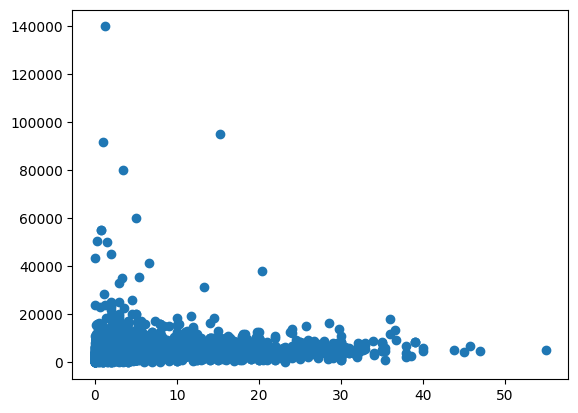

In [48]:
df['Time_At_Job'] = (df['intYears'] * 12 + df['intMonths']) / 12
x = np.array(df['Time_At_Job'])
y= np.array(df['fltGrossMonthly'])

plt.scatter(x,y)
plt.show()

In [54]:
print(df.loc[df['fltGrossMonthly'] == 140000])

      bigIncomeId        dtmStampCreation  fltGrossMonthly strEmployerName  \
1085     13784659 2024-05-28 11:06:48.353         140000.0         US NAVY   

      intMonths  intYears fltGrossMonthly_cat  Time_At_Job  
1085        3.0       1.0             Not Low         1.25  


In [ ]:
cls_get_data.str_query

In [ ]:
os.listdir(str_dirname_output)

In [ ]:
cls_get_data.str_query